## Circuit with H, X, CNOT

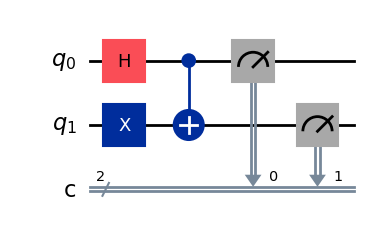

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

# Create circuit
qc = QuantumCircuit(2, 2)

# Step 1: Apply Hadamard → superposition
qc.h(0)

# Step 2: Apply X on second qubit
qc.x(1)

# Step 3: Apply CNOT (entanglement)
qc.cx(0, 1)

# Measurement
qc.measure([0,1], [0,1])

# Draw circuit
qc.draw('mpl')

## State Evolution (Before Measurement)

In [2]:
# Statevector (no measurement)
qc_sv = QuantumCircuit(2)
qc_sv.h(0)
qc_sv.x(1)
qc_sv.cx(0,1)

sv = Statevector.from_instruction(qc_sv)
print(sv)

Statevector([0.        +0.j, 0.70710678+0.j, 0.70710678+0.j,
             0.        +0.j],
            dims=(2, 2))


In [3]:
sim = AerSimulator()
result = sim.run(qc, shots=1024).result()
counts = result.get_counts()

print(counts)
plot_histogram(counts)
plt.show()

{'10': 509, '01': 515}


## Toffoli Gate Demonstration

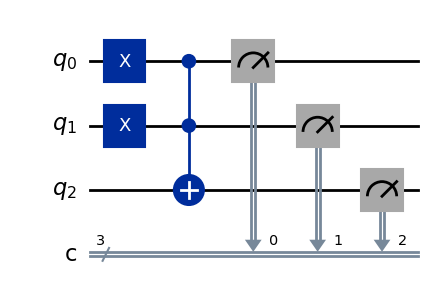

In [4]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# 3-qubit circuit
qc = QuantumCircuit(3, 3)

# Initialize |110>
qc.x(0)
qc.x(1)

# Apply Toffoli
qc.ccx(0, 1, 2)

# Measurement
qc.measure([0,1,2], [0,1,2])

qc.draw('mpl')

## Statevector Analysis

In [5]:
qc_sv = QuantumCircuit(3)

qc_sv.x(0)
qc_sv.x(1)

qc_sv.ccx(0,1,2)

sv = Statevector.from_instruction(qc_sv)
print(sv)

Statevector([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             1.+0.j],
            dims=(2, 2, 2))


In [6]:
sim = AerSimulator()
result = sim.run(qc, shots=1024).result()
counts = result.get_counts()

print(counts)
plot_histogram(counts)
plt.show()

{'111': 1024}
